In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
project_root = Path.cwd().parent
processed_data_dir = project_root / "data" / "processed"

print(project_root)
print(processed_data_dir)

c:\Users\MiGoreng\OneDrive\Documents\GitHub\healthcare-analytics-platform
c:\Users\MiGoreng\OneDrive\Documents\GitHub\healthcare-analytics-platform\data\processed


In [5]:
X_train = pd.read_csv(processed_data_dir / "X_train.csv")
X_test = pd.read_csv(processed_data_dir /"X_test.csv")

y_train = pd.read_csv(processed_data_dir / "y_train.csv").squeeze()
y_test = pd.read_csv(processed_data_dir / "y_test.csv").squeeze()

In [9]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")

Training data shape: (4034, 5)
Test data shape: (1730, 5)
Training target shape: (4034,)
Test target shape: (1730,)


In [11]:
X_train.head()

,age,gender,bmi,encounter_count,hypertension
0,75,M,30.4,43,1
1,50,F,30.0,64,0
2,56,F,30.3,653,1
3,10,F,83.1,26,0
4,20,F,86.4,36,0


In [12]:
y_train.head()

0    1
1    0
2    1
3    0
4    0
Name: diabetes, dtype: int64

In [16]:
numeric_features = [
    "age",
    "bmi",
    "encounter_count"
]

binary_features = [
    "hypertension"
]

categorical_features = [
    "gender"
]

In [17]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [18]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            )
        )
    ]
)

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [20]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=123
            )
        )
    ]
)

In [21]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['age','gender','bmi','encounter_count','hypertension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [22]:
y_pred = logistic_model.predict(X_test)

In [23]:
prediction_preview = pd.DataFrame({
    "actual": y_test.iloc[:10].values,
    "predicted": y_pred[:10]
})

prediction_preview

,actual,predicted
0,1,1
1,1,0
2,1,0
3,0,1
4,0,0
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


In [24]:
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

In [25]:
probability_preview = pd.DataFrame({
    "actual": y_test.iloc[:10].values,
    "predicted_class": y_pred[:10],
    "predicted_probability": y_pred_proba[:10]
})

probability_preview

,actual,predicted_class,predicted_probability
0,1,1,0.733673
1,1,0,0.428434
2,1,0,0.319859
3,0,1,0.638349
4,0,0,0.126356
5,0,0,0.073187
6,1,1,0.983524
7,0,0,0.312446
8,1,1,0.830254
9,1,1,0.811456


In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [27]:
logistic_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 score",
        "ROC AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

logistic_metrics["Value"] = logistic_metrics["Value"].round(3)

logistic_metrics

,Metric,Value
0,Accuracy,0.752
1,Precision,0.702
2,Recall,0.719
3,F1 score,0.710
4,ROC AUC,0.846


In [30]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No diabetes",
            "Diabetes"
        ]
    )
)

              precision    recall  f1-score   support

 No diabetes       0.79      0.78      0.78       998
    Diabetes       0.70      0.72      0.71       732

    accuracy                           0.75      1730
   macro avg       0.75      0.75      0.75      1730
weighted avg       0.75      0.75      0.75      1730



In [31]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[775, 223],
       [206, 526]])

In [32]:
tn, fp, fn, tp = cm.ravel()

print(f"True negatives:  {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives:  {tp}")

True negatives:  775
False positives: 223
False negatives: 206
True positives:  526


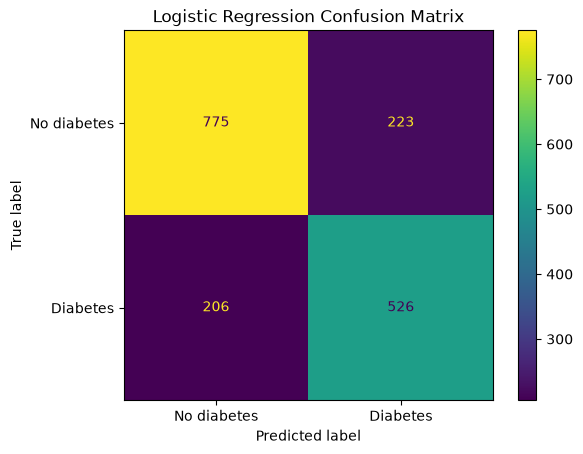

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "No diabetes",
        "Diabetes"
    ],
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

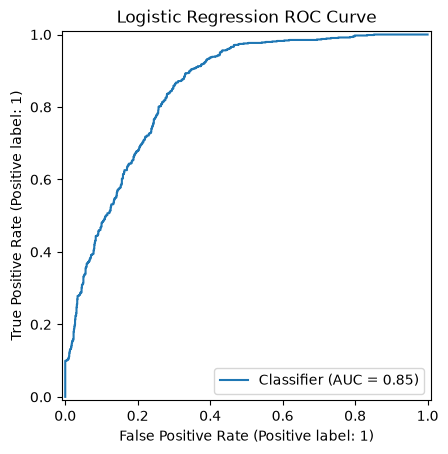

In [34]:
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba
)

plt.title("Logistic Regression ROC Curve")
plt.show()

In [35]:
fitted_imputer = (
    logistic_model
    .named_steps["preprocessor"]
    .named_transformers_["numeric"]
    .named_steps["imputer"]
)

imputation_values = pd.Series(
    fitted_imputer.statistics_,
    index=numeric_features,
    name="Imputation value"
)

imputation_values

age                42.0
bmi                30.3
encounter_count    36.0
Name: Imputation value, dtype: float64

In [36]:
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_names

array(['numeric__age', 'numeric__bmi', 'numeric__encounter_count',
       'binary__hypertension', 'categorical__gender_M'], dtype=object)

In [37]:
coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_table = coefficient_table.sort_values(
    "Coefficient",
    ascending=False
)

coefficient_table

,Feature,Coefficient
0,numeric__age,1.072119
2,numeric__encounter_count,0.758603
3,binary__hypertension,0.618975
4,categorical__gender_M,0.128392
1,numeric__bmi,-0.767679


In [38]:
import numpy as np

coefficient_table["Odds ratio"] = np.exp(
    coefficient_table["Coefficient"]
)

coefficient_table[
    [
        "Feature",
        "Coefficient",
        "Odds ratio"
    ]
]

,Feature,Coefficient,Odds ratio
0,numeric__age,1.072119,2.921565
2,numeric__encounter_count,0.758603,2.135292
3,binary__hypertension,0.618975,1.857024
4,categorical__gender_M,0.128392,1.136999
1,numeric__bmi,-0.767679,0.464089


## Save the outputs

In [39]:
model_output_dir = project_root / "outputs" / "models"
model_output_dir.mkdir(parents=True, exist_ok=True)

In [40]:
logistic_metrics.to_csv(
    model_output_dir / "logistic_regression_metrics.csv",
    index=False
)

In [41]:
coefficient_table.to_csv(
    model_output_dir / "logistic_regression_coefficients.csv",
    index=False
)

## Logistic regression summary

A logistic regression pipeline was fitted using the training dataset.

The pipeline:

- imputed missing BMI values using the training-set median
- standardised age, BMI, and encounter count
- retained hypertension as a binary 0/1 predictor
- one-hot encoded gender
- predicted documented diabetes

Model performance was evaluated on the held-out test dataset using accuracy,
precision, recall, F1 score, ROC AUC, and a confusion matrix.

The resulting coefficients describe predictive associations after accounting
for the other model features. They should not be interpreted as evidence of
causal relationships.